# Computational Exercises 5

## Exercise 1

The following code implements the projection problem in an arbitrary domain, with any function space and the H1 and L2 inner products

In [1]:
import firedrake as fd
from firedrake.output import VTKFile 
from firedrake.__future__ import interpolate
import numpy as np
import matplotlib.pyplot as plt

def innerL2(u,v):
    return fd.inner(u,v) * fd.dx

def innerH1(u, v):
    return (fd.inner(u,v) + fd.inner(fd.grad(u), fd.grad(v))) * fd.dx


def solveProjection(mesh, u, Vh, inner_type: str):
    uTrial, vh = fd.TrialFunction(Vh), fd.TestFunction(Vh)

    a: ufl.form.Form
    L: ufl.form.Form
    if inner_type == "H1":
        a = innerH1(uTrial, vh)
        L = innerH1(u, vh)
    elif inner_type == "L2":
        a = innerL2(uTrial, vh)
        L = innerL2(u, vh)
    else:
        print("inner type undefined")

    uh = fd.Function(Vh)
    opts={"ksp_type": "preonly", "pc_type": "lu"}
    fd.solve(a == L, uh, solver_parameters=opts)
    
    return uh



firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


## Exercise 2

We're assuming $\Omega = [0,1]$ and $u(x)= sin(2 \pi x)$

In [2]:
lncells = [1, 2, 4, 8, 12, 16, 32]
interval_length = 1.0

#Part 1
lorder = [0, 1, 2]
luhL2 = [[], [], []] #luhL2[i] is the list with results of order i

for i, order in enumerate(lorder):
    for ncells in lncells:
        mesh = fd.IntervalMesh(ncells, interval_length)
        Vh = fd.FunctionSpace(mesh, "DG", degree=order, variant="equispaced")

        x = fd.SpatialCoordinate(mesh)
        u = fd.sin(2* np.pi * x[0])

        uh = solveProjection(mesh, u, Vh, "L2")
        luhL2[i].append(uh)

#Part 2
lorder = [1, 2, 3]
luhH1 = [[], [], []] #luhH1[i] is the list with results of order i
for i, order in enumerate(lorder):
    for ncells in lncells:
        mesh = fd.IntervalMesh(ncells, interval_length)
        Vh = fd.FunctionSpace(mesh, "CG", degree=order, variant="equispaced")

        x = fd.SpatialCoordinate(mesh)
        u = fd.sin(2* np.pi * x[0])

        uh = solveProjection(mesh, u, Vh, "H1")
        luhH1[i].append(uh)


#Part 3
for i in range(3): 
    for j, ncells in enumerate(lncells):
        print(f" {ncells} cells: \tDG{i}: {len(luhL2[i][j].dat.data[:])}; \t CG{i+1}: {len(luhH1[i][j].dat.data[:])}")
    print("")

 1 cells: 	DG0: 1; 	 CG1: 2
 2 cells: 	DG0: 2; 	 CG1: 3
 4 cells: 	DG0: 4; 	 CG1: 5
 8 cells: 	DG0: 8; 	 CG1: 9
 12 cells: 	DG0: 12; 	 CG1: 13
 16 cells: 	DG0: 16; 	 CG1: 17
 32 cells: 	DG0: 32; 	 CG1: 33

 1 cells: 	DG1: 2; 	 CG2: 3
 2 cells: 	DG1: 4; 	 CG2: 5
 4 cells: 	DG1: 8; 	 CG2: 9
 8 cells: 	DG1: 16; 	 CG2: 17
 12 cells: 	DG1: 24; 	 CG2: 25
 16 cells: 	DG1: 32; 	 CG2: 33
 32 cells: 	DG1: 64; 	 CG2: 65

 1 cells: 	DG2: 3; 	 CG3: 4
 2 cells: 	DG2: 6; 	 CG3: 7
 4 cells: 	DG2: 12; 	 CG3: 13
 8 cells: 	DG2: 24; 	 CG3: 25
 12 cells: 	DG2: 36; 	 CG3: 37
 16 cells: 	DG2: 48; 	 CG3: 49
 32 cells: 	DG2: 96; 	 CG3: 97



Notice that for the Discontinuous Galerkin, the size of the vector is always $ncells \cdot (order+1)$. This is due to the fact that, to form a polynomial of degree $k$, we need $k+1$ degrees of freedom (DoF). As we have one polynomial for each element, we need $ncells \cdot (order+1)$ parameters in total. Firedrake uses $k+1$ polynomials $\phi_i$ for each element such that $\phi_i(\xi_i) = 1$, $\phi_i(\xi_j) = 0$ and $\phi_i=0$ outside the element ($i = 1, \dots, k$ and $j \ne i$), where $\xi_i$ is the i-th DoF of that element (usually they're equally spaced). So, actually, the coefficients $U_i$ of those $\phi_i$ functions are just the value of $\sum_i U_i \phi_i(\xi_i)$.

For the Continuous Galerkin case, we see that the size of the vector is $ncells \cdot order + 1$. So the number of DoFs of a CG solution is always lower than the DoFs of a DG solutions, as the continuity constraint makes that adjacent cells share values. The last DoF of a cell is the same DoF of the beginning of the next cell.

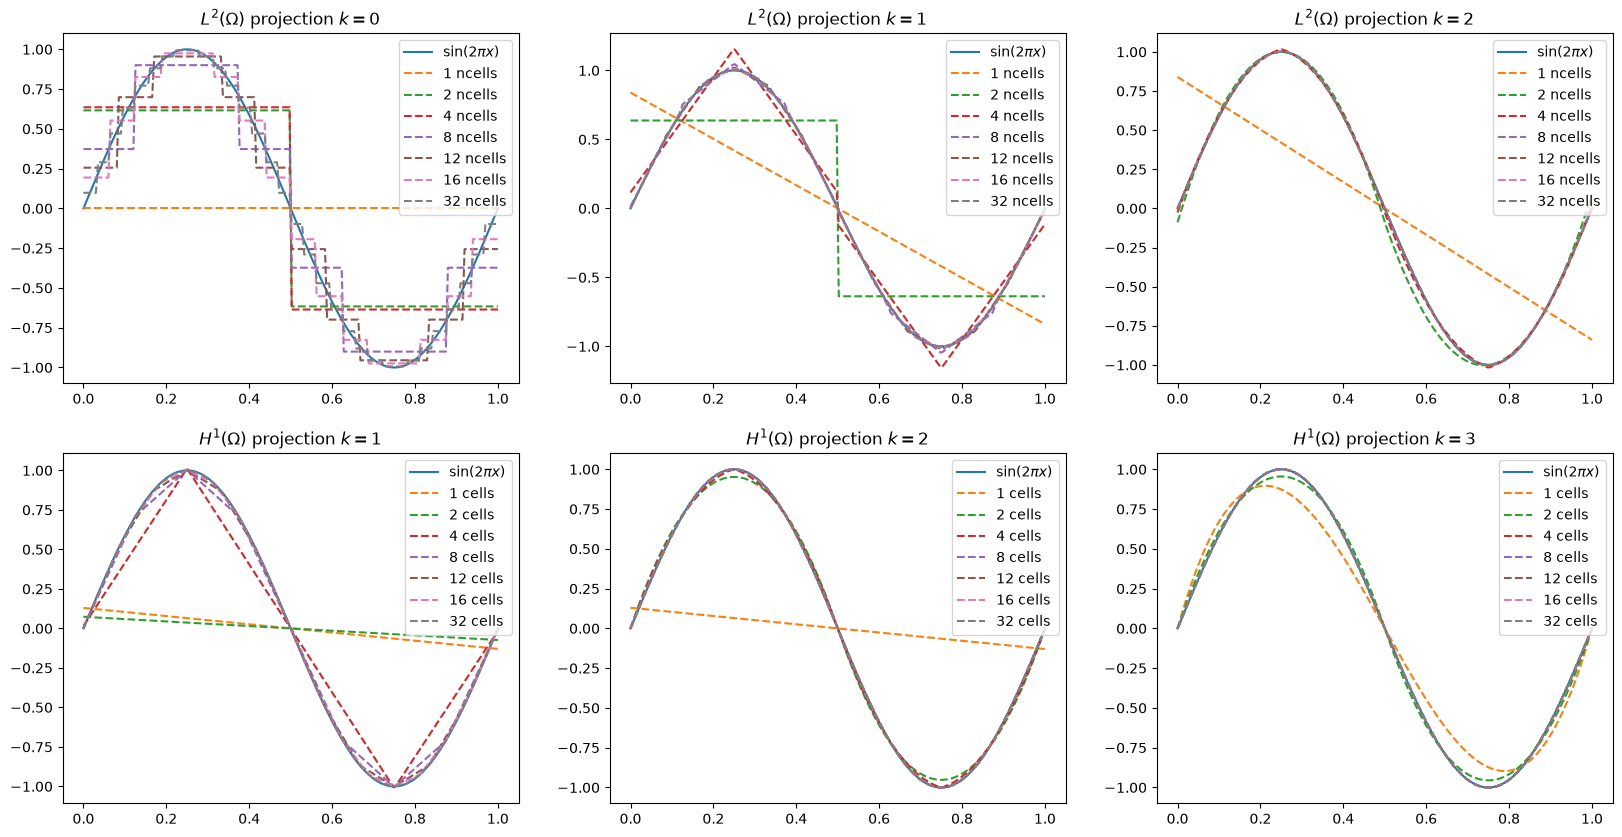

In [11]:

fig = plt.figure(figsize=(2000, 1000, "px"))

x= np.linspace(0.0, 1.0, 200)
ysin = np.sin(x * np.pi * 2)
#Plotting DG
for i in range(3):
    axnum = 230 + i + 1
    axDG = fig.add_subplot(axnum)
    axDG.set_title(rf"$L^2(\Omega)$ projection $k={i}$")
    axDG.plot(x, ysin, label=r"$\sin(2\pi x)$") 
    for j, ncells in enumerate(lncells):
        h = 1.0/ncells
        y = np.zeros_like(x)
        for k in range(ncells):
            x_i = h*k
            x_f = h*(k+1)
            xcell = np.linspace(x_i, x_f, i+1)
            if i == 0:
                xcell = np.array([x_f- x_i])
            p: np.ndarray
            if i == 2: #Breaks for order 2, for some reason
                v = []
                for m in xcell:
                    v.append(luhL2[i][j](m))
                p = np.polyfit(xcell, v, i)
            else:
                p = np.polyfit(xcell, luhL2[i][j].dat.data[k*(i+1):(k+1)*(i+1)], i)
            
            args = np.argwhere((x>= x_i) & (x<=x_f))
            y[args] = np.polyval(p, x[args])
        axDG.plot(x, y, '--', label=f"{ncells} ncells")
        axDG.legend()

VTKFile("Solutions/test.pvd").write(luhH1[2][3])

#Plotting CG
for i in range(3):
    axnum = 230 + i + 4
    axDG = fig.add_subplot(axnum)
    axDG.set_title(rf"$H^1(\Omega)$ projection $k={i+1}$")
    axDG.plot(x, ysin, label=r"$\sin(2\pi x)$") 
    for j, ncells in enumerate(lncells):
        h = 1.0/ncells
        y = np.zeros_like(x)
        for k in range(ncells):
            x_i = h*k
            x_f = h*(k+1)
            xcell = np.linspace(x_i, x_f, i+2)
            p:np.ndarray
            if k != 0:
                p = np.polyfit(xcell, luhH1[i][j].dat.data[k*(i+1):k*(i+1)+(i+2)], i+1)
            elif k == 0 and i >= 1: #for some reason, accessing with dat.data is broken for higher orders and specifically the first cell
                v = []
                for m in xcell:
                    v.append(luhH1[i][j](m))
                p = np.polyfit(xcell, v, i+1)
            else:
                p = np.polyfit(xcell, luhH1[i][j].dat.data[0:i+2], i+1)
            args = np.argwhere((x>= x_i) & (x<=x_f))
            y[args] = np.polyval(p, x[args])
        axDG.plot(x, y, '--', label=f"{ncells} cells")
        axDG.legend()


## Exercise 3

Now $\Omega = [0,1]^2$ and $u(x_1, x_2) = \sin(\pi x_1) \sin(\pi x_2)$

In [37]:
Nx, Ny = 32, 32
Lx, Ly = 1.0, 1.0
mesh = fd.RectangleMesh(Nx, Ny, Lx, Ly, quadrilateral=False)
x = fd.SpatialCoordinate(mesh)

VhL2 = fd.FunctionSpace(mesh, "DG", degree=0)
VhH1 = fd.FunctionSpace(mesh, "CG", degree=1)
u = fd.sin(np.pi * x[0]) * fd.sin( np.pi * x[1])

uhL2 = solveProjection(mesh, u, VhL2, "L2")
uhH1 = solveProjection(mesh, u, VhH1, "H1")

VTKFile("Solutions/uhL2.pvd").write(uhL2)
VTKFile("Solutions/uhH1.pvd").write(uhH1)

We can see the projections:

- $L^2(\Omega)$ projection in Discontinuous Galerkin space

![](imgs/uhL2.png)

- $H^1(\Omega)$ projection in Continuous Galerkin space (order 1)

![](imgs/uhH1.png)